In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from pathlib import Path
from keras import layers
from keras import ops
from keras import optimizers
from keras import metrics
from keras import Model
from keras.applications import resnet
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

target_shape = (200, 200)

In [2]:
base_path = Path("../Clustering/hasil_clustering")  # Sesuaikan dengan path Anda

In [3]:
def preprocess_image(filename):
    """
    Load the specified file as a JPEG image, preprocess it and
    resize it to the target shape.
    """
    image_string = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image_string, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, target_shape)
    return image

def preprocess_triplets(anchor, positive, negative):
    """
    Given the filenames corresponding to the three images, load and
    preprocess them.
    """
    return (
        preprocess_image(anchor),
        preprocess_image(positive),
        preprocess_image(negative),
    )

In [4]:
def create_triplet_dataset(base_path, num_clusters=629):
    """
    Membuat dataset dengan strategi rotasi anchor dan augmentasi
    """
    all_triplets = []
    
    # Iterasi setiap cluster
    for cluster_id in range(1, num_clusters + 1):
        cluster_path = base_path / f"cluster_{cluster_id}"
        if not cluster_path.exists():
            continue
            
        images = list(cluster_path.glob("*.png")) + list(cluster_path.glob("*.jpg")) + list(cluster_path.glob("*.jpeg"))
        
        if len(images) < 2:
            continue
            
        # Buat lebih banyak kombinasi anchor-positive
        for i, anchor in enumerate(images):
            # Gunakan beberapa positive dari cluster yang sama
            for j in range(min(3, len(images))):  # Ambil sampai 3 positive
                positive = images[(i + j + 1) % len(images)]
                
                # Pilih beberapa negative dari cluster lain
                other_clusters = [x for x in range(1, num_clusters + 1) 
                                if x != cluster_id and (base_path / f"cluster_{x}").exists()]
                
                if not other_clusters:
                    continue
                    
                # Ambil beberapa negative untuk setiap pair anchor-positive
                for _ in range(2):  # Ambil 2 negative untuk setiap pair
                    neg_cluster = np.random.choice(other_clusters)
                    neg_path = base_path / f"cluster_{neg_cluster}"
                    neg_images = list(neg_path.glob("*.png")) + list(neg_path.glob("*.jpg")) + list(neg_path.glob("*.jpeg"))
                    
                    if not neg_images:
                        continue
                        
                    negative = np.random.choice(neg_images)
                    all_triplets.append((str(anchor), str(positive), str(negative)))
    
    # Acak dataset
    np.random.shuffle(all_triplets)
    
    # Split train-validation
    train_size = int(0.8 * len(all_triplets))
    train_triplets = all_triplets[:train_size]
    val_triplets = all_triplets[train_size:]
    
    # Buat tf.data.Dataset dengan augmentasi
    def augment_image(image):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, 0.2)
        image = tf.image.random_contrast(image, 0.8, 1.2)
        return image
    
    def preprocess_triplets_with_aug(anchor, positive, negative):
        return (
            augment_image(preprocess_image(anchor)),
            augment_image(preprocess_image(positive)),
            augment_image(preprocess_image(negative)),
        )
    
    def create_tf_dataset(triplets, batch_size=32):
        anchors = [t[0] for t in triplets]
        positives = [t[1] for t in triplets]
        negatives = [t[2] for t in triplets]
        
        dataset = tf.data.Dataset.from_tensor_slices((anchors, positives, negatives))
        dataset = dataset.map(preprocess_triplets_with_aug)
        dataset = dataset.batch(batch_size)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)
        return dataset
    
    train_dataset = create_tf_dataset(train_triplets)
    val_dataset = create_tf_dataset(val_triplets)
    
    return train_dataset, val_dataset

In [5]:
# Gunakan fungsi untuk membuat dataset
train_dataset, val_dataset = create_triplet_dataset(base_path)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10143876..1.087225].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.17456156..1.0979923].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11991826..1.0029073].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.09414631..1.0237088].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03767681..1.1448472].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.097607285..0.7909521].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00

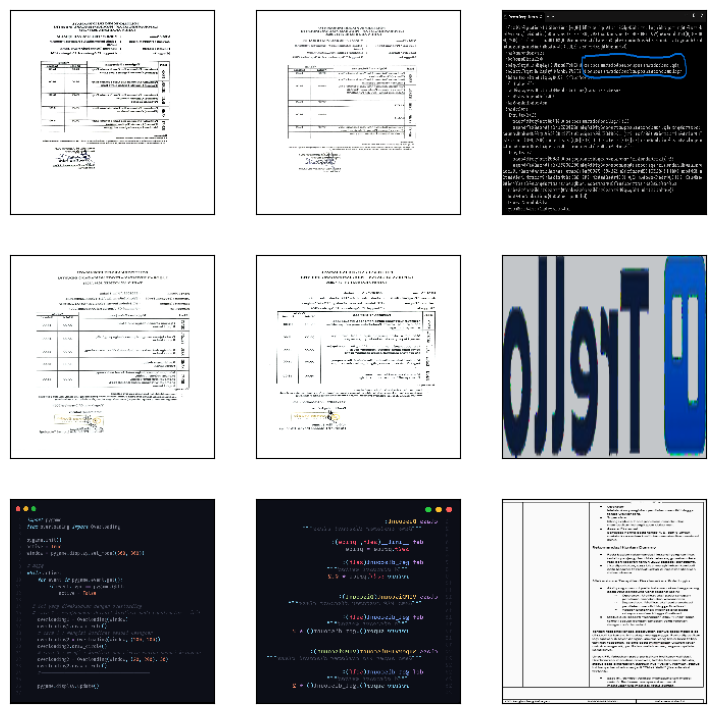

In [6]:
def visualize(anchor, positive, negative):
    """Visualize a few triplets from the supplied batches."""

    def show(ax, image):
        ax.imshow(image)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    fig = plt.figure(figsize=(9, 9))

    axs = fig.subplots(3, 3)
    for i in range(3):
        show(axs[i, 0], anchor[i])
        show(axs[i, 1], positive[i])
        show(axs[i, 2], negative[i])


visualize(*list(train_dataset.take(1).as_numpy_iterator())[0])

In [7]:
base_cnn = resnet.ResNet50(
    weights="imagenet", input_shape=target_shape + (3,), include_top=False
)

flatten = layers.Flatten()(base_cnn.output)
dense1 = layers.Dense(512, activation="relu")(flatten)
dense1 = layers.BatchNormalization()(dense1)
dense2 = layers.Dense(256, activation="relu")(dense1)
dense2 = layers.BatchNormalization()(dense2)
output = layers.Dense(256)(dense2)

embedding = Model(base_cnn.input, output, name="Embedding")

trainable = False
for layer in base_cnn.layers:
    if layer.name == "conv5_block1_out":
        trainable = True
    layer.trainable = trainable

In [8]:
class DistanceLayer(layers.Layer):
    """
    This layer is responsible for computing the distance between the anchor
    embedding and the positive embedding, and the anchor embedding and the
    negative embedding.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, anchor, positive, negative):
        ap_distance = ops.sum(tf.square(anchor - positive), -1)
        an_distance = ops.sum(tf.square(anchor - negative), -1)
        return (ap_distance, an_distance)


anchor_input = layers.Input(name="anchor", shape=target_shape + (3,))
positive_input = layers.Input(name="positive", shape=target_shape + (3,))
negative_input = layers.Input(name="negative", shape=target_shape + (3,))

distances = DistanceLayer()(
    embedding(resnet.preprocess_input(anchor_input)),
    embedding(resnet.preprocess_input(positive_input)),
    embedding(resnet.preprocess_input(negative_input)),
)

siamese_network = Model(
    inputs=[anchor_input, positive_input, negative_input], outputs=distances
)


In [9]:
def plot_training_history(history, epochs):
    def moving_average(data, window_size=3):
        return np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
    
    # Smooth the curves
    train_loss = moving_average(history.history['loss'])
    val_loss = moving_average(history.history['val_loss'])
    epochs_range = range(len(train_loss))
    
    # Plot Loss
    ax1.plot(epochs_range, train_loss, 
             label='train', color='#1f77b4', linewidth=2)
    ax1.plot(epochs_range, val_loss, 
             label='validation', color='#ff7f0e', linewidth=2)
    ax1.set_title('Model Loss', pad=20, size=14, weight='bold')
    ax1.set_xlabel('epoch')
    ax1.set_ylabel('loss')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.set_ylim([0, 0.25])  # Set consistent y-axis limits
    
    # Calculate and smooth accuracy
    train_acc = moving_average([1 - min(l, 1) for l in history.history['loss']])
    val_acc = moving_average([1 - min(l, 1) for l in history.history['val_loss']])
    
    # Plot Accuracy
    ax2.plot(epochs_range, train_acc, 
             label='train', color='#1f77b4', linewidth=2)
    ax2.plot(epochs_range, val_acc, 
             label='validation', color='#ff7f0e', linewidth=2)
    ax2.set_title('Model Accuracy', pad=20, size=14, weight='bold')
    ax2.set_xlabel('epoch')
    ax2.set_ylabel('accuracy')
    ax2.set_ylim([0.5, 1.0])  # Set consistent y-axis limits
    ax2.legend(loc='lower right')
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [10]:
class SiameseModel(Model):
    """The Siamese Network model with a custom training and testing loops.

    Computes the triplet loss using the three embeddings produced by the
    Siamese Network.

    The triplet loss is defined as:
       L(A, P, N) = max(‖f(A) - f(P)‖² - ‖f(A) - f(N)‖² + margin, 0)
    """

    def __init__(self, siamese_network, margin=0.5):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = metrics.Mean(name="loss")

    def call(self, inputs):
        return self.siamese_network(inputs)

    def train_step(self, data):
        # GradientTape is a context manager that records every operation that
        # you do inside. We are using it here to compute the loss so we can get
        # the gradients and apply them using the optimizer specified in
        # `compile()`.
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data)

        # Storing the gradients of the loss function with respect to the
        # weights/parameters.
        gradients = tape.gradient(loss, self.siamese_network.trainable_weights)

        # Applying the gradients on the model using the specified optimizer
        self.optimizer.apply_gradients(
            zip(gradients, self.siamese_network.trainable_weights)
        )

        # Let's update and return the training loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        loss = self._compute_loss(data)

        # Let's update and return the loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def _compute_loss(self, data):
        # The output of the network is a tuple containing the distances
        # between the anchor and the positive example, and the anchor and
        # the negative example.
        ap_distance, an_distance = self.siamese_network(data)

        # Computing the Triplet Loss by subtracting both distances and
        # making sure we don't get a negative value.
        loss = ap_distance - an_distance
        loss = tf.maximum(loss + self.margin, 0.0)
        return loss

    @property
    def metrics(self):
        # We need to list our metrics here so the `reset_states()` can be
        # called automatically.
        return [self.loss_tracker]

In [11]:
# Learning rate scheduling untuk transisi yang lebih smooth
initial_learning_rate = 0.0001
decay_steps = 1000
decay_rate = 0.9

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps,
    decay_rate
)

# Tambahkan callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

Epoch 1/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 4253s 4s/step - loss: 0.1447 - val_loss: 0.0766
Epoch 2/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 4539s 4s/step - loss: 0.0653 - val_loss: 0.0555
Epoch 3/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 4162s 4s/step - loss: 0.0528 - val_loss: 0.0600
Epoch 4/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 4164s 4s/step - loss: 0.0491 - val_loss: 0.0485
Epoch 5/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 4191s 4s/step - loss: 0.0391 - val_loss: 0.0459
Epoch 6/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 4159s 4s/step - loss: 0.0370 - val_loss: 0.0372
Epoch 7/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 4183s 4s/step - loss: 0.0348 - val_loss: 0.0395
Epoch 8/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 4203s 4s/step - loss: 0.0303 - val_loss: 0.0373
Epoch 9/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 4251s 4s/step - loss: 0.0284 - val_loss: 0.0355
Epoch 10/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 4193s 4s/step - loss: 0.0261 - val_loss: 0.0297


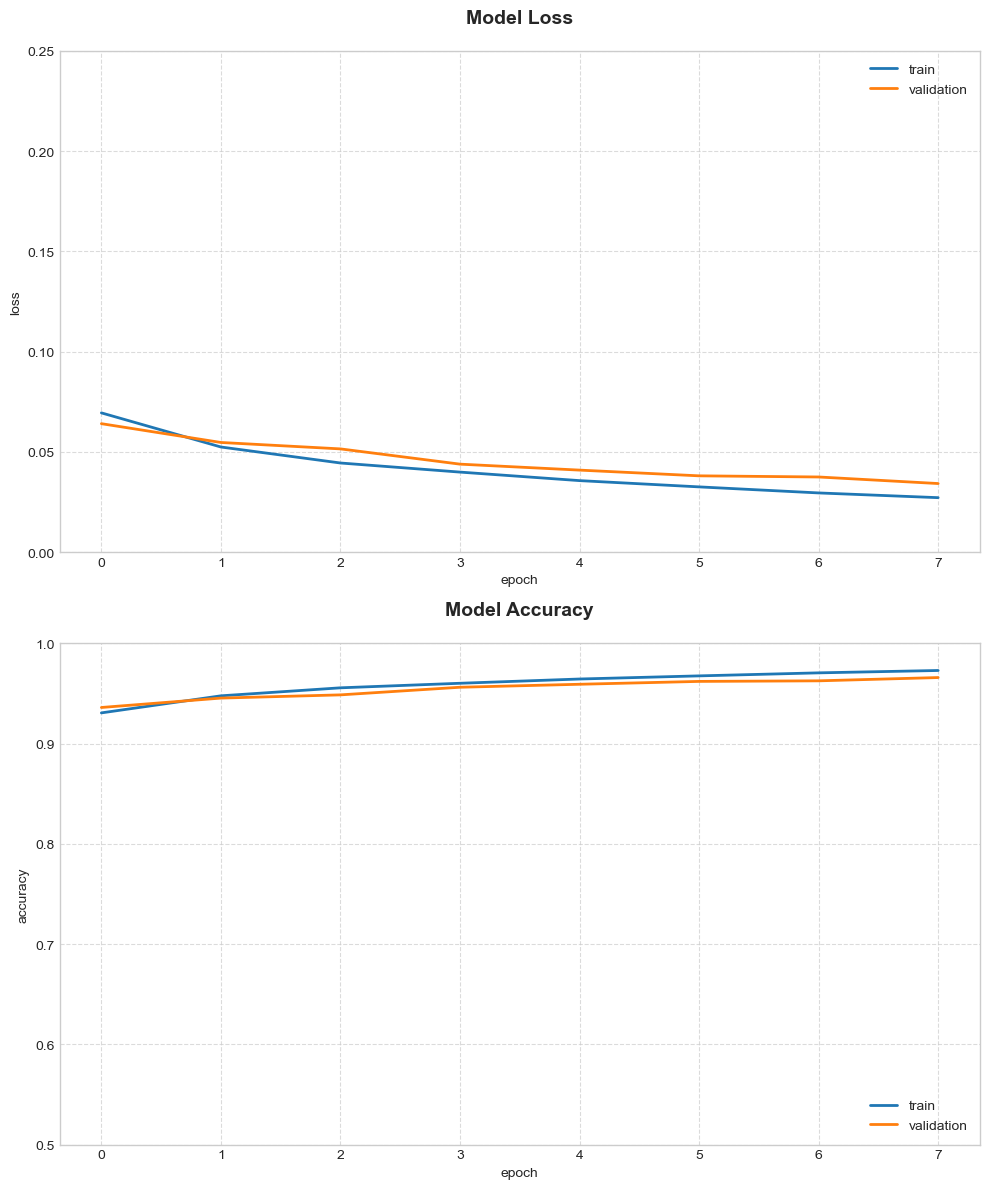

In [12]:
siamese_model = SiameseModel(siamese_network)
siamese_model.compile(optimizer=optimizers.Adam(0.0001))
# Training dengan metrics baru
history = siamese_model.fit(
    train_dataset, 
    epochs=10, 
    validation_data=val_dataset
)

# Plot hasil training
plot_training_history(history, 10)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.19805348..1.0479898].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.23766434..1.1107057].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.045538664..0.9529162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0728575..0.96791786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.17782193..1.0738044].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.113969624..0.69917077].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1

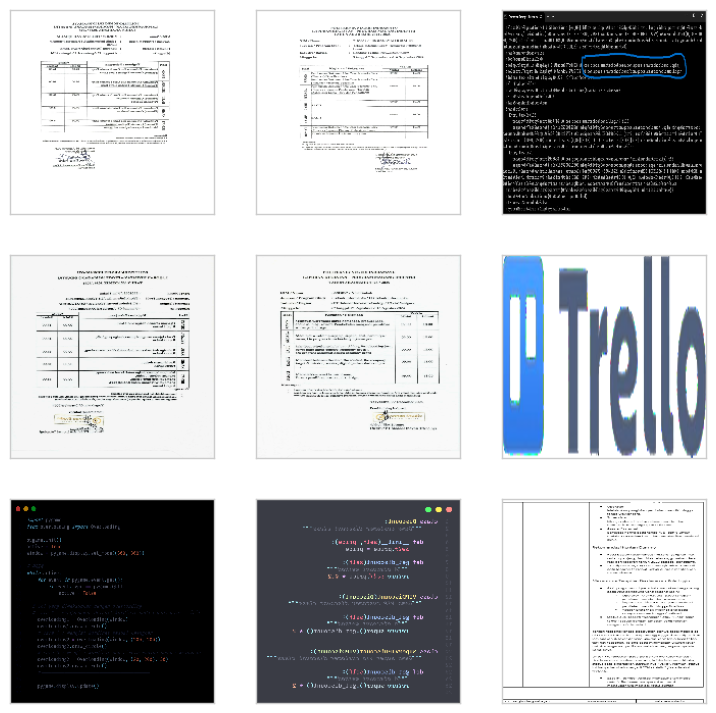

In [13]:
sample = next(iter(train_dataset))
visualize(*sample)

anchor, positive, negative = sample
anchor_embedding, positive_embedding, negative_embedding = (
    embedding(resnet.preprocess_input(anchor)),
    embedding(resnet.preprocess_input(positive)),
    embedding(resnet.preprocess_input(negative)),
)

Mengevaluasi model...

Hasil Evaluasi:
Accuracy: 0.5000
Precision: 0.5000
Recall: 1.0000
F1-Score: 0.6667

Membuat visualisasi...


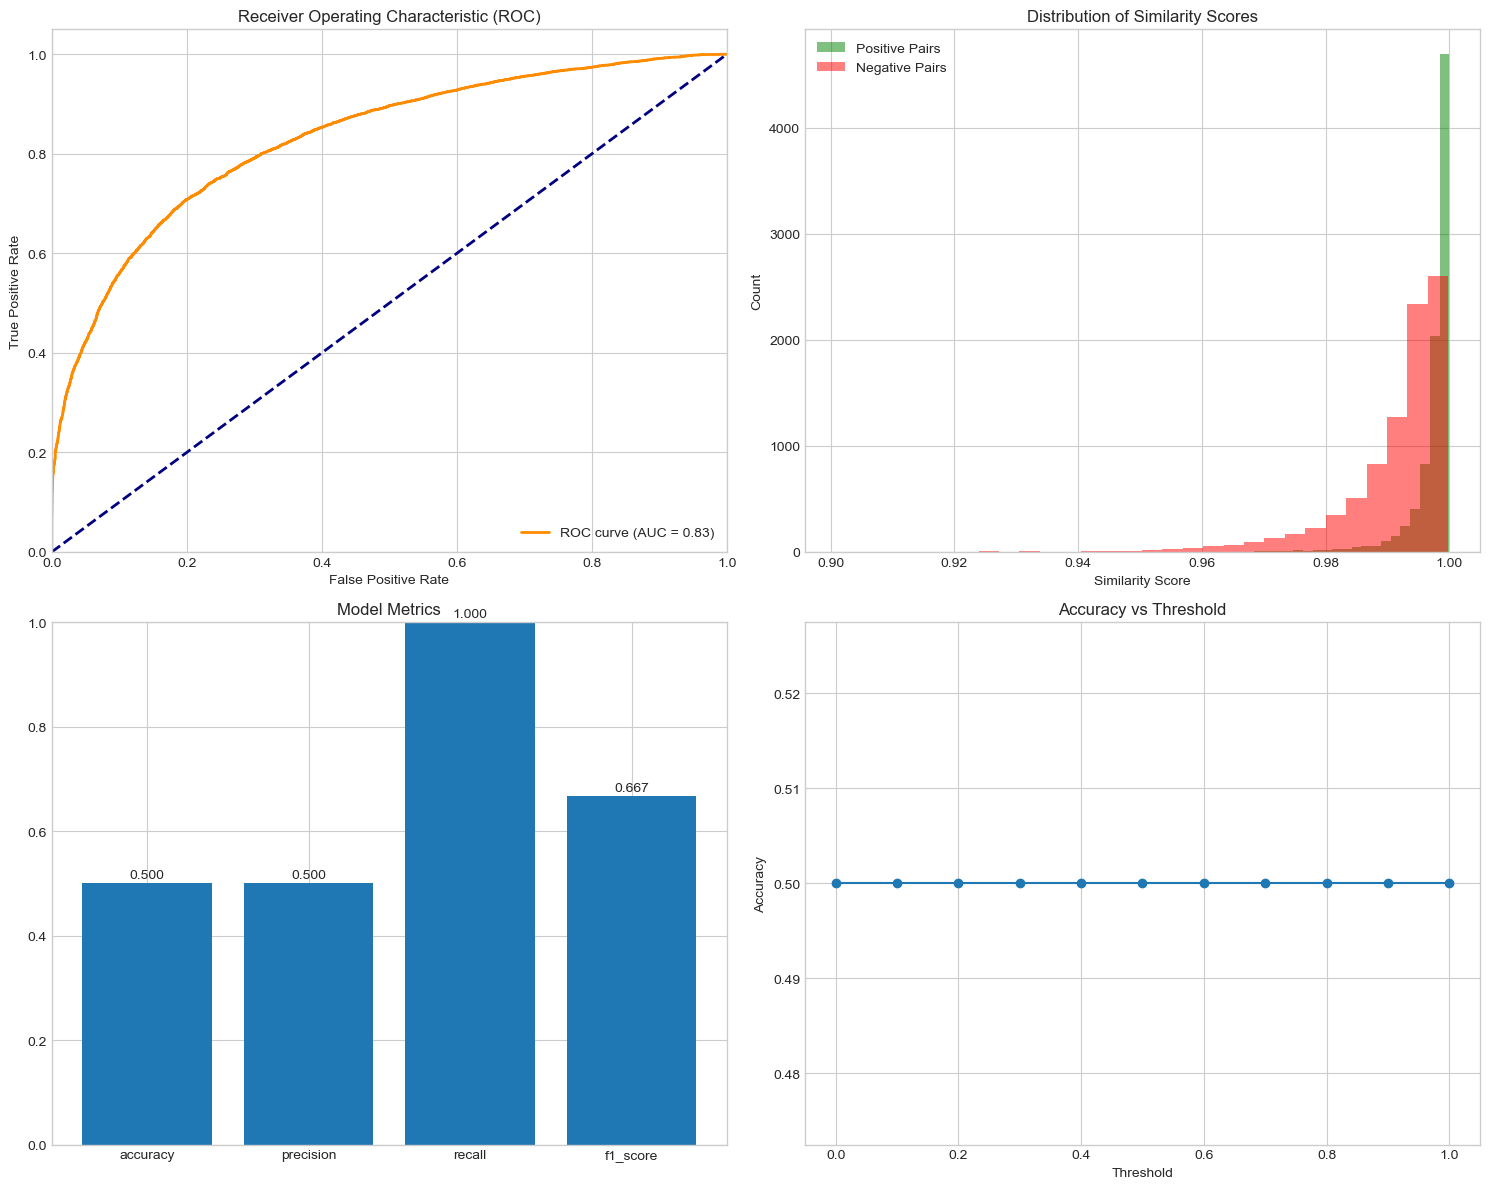

In [14]:
def compute_embeddings(images, embedding_model):
    """
    Menghitung embeddings untuk batch gambar
    """
    return embedding_model(images)

def compute_similarities(anchor_emb, comparison_emb):
    """
    Menghitung cosine similarity antara dua embedding
    """
    # Normalisasi embeddings
    anchor_emb = tf.math.l2_normalize(anchor_emb, axis=1)
    comparison_emb = tf.math.l2_normalize(comparison_emb, axis=1)
    
    # Hitung cosine similarity
    return tf.reduce_sum(anchor_emb * comparison_emb, axis=1)

def evaluate_siamese_model(dataset, embedding_model, threshold=0.5):
    """
    Evaluasi model dengan berbagai metrik
    """
    # Inisialisasi metrics
    accuracy_metric = BinaryAccuracy()
    precision_metric = Precision()
    recall_metric = Recall()
    
    # Lists untuk menyimpan semua predictions dan true labels
    all_similarities = []
    all_labels = []
    
    for batch in dataset:
        # Asumsikan batch berisi (anchor, positive, negative)
        if len(batch) == 3:
            anchor, positive, negative = batch
        else:
            print("Unexpected batch format")
            continue
            
        # Compute embeddings
        anchor_emb = compute_embeddings(anchor, embedding_model)
        positive_emb = compute_embeddings(positive, embedding_model)
        negative_emb = compute_embeddings(negative, embedding_model)
        
        # Compute similarities
        positive_similarities = compute_similarities(anchor_emb, positive_emb)
        negative_similarities = compute_similarities(anchor_emb, negative_emb)
        
        # Buat labels
        batch_size = tf.shape(positive_similarities)[0]
        positive_labels = tf.ones(batch_size)
        negative_labels = tf.zeros(batch_size)
        
        # Gabungkan similarities dan labels
        batch_similarities = tf.concat([positive_similarities, negative_similarities], axis=0)
        batch_labels = tf.concat([positive_labels, negative_labels], axis=0)
        
        # Update metrics
        predictions = tf.cast(batch_similarities > threshold, tf.float32)
        
        accuracy_metric.update_state(batch_labels, predictions)
        precision_metric.update_state(batch_labels, predictions)
        recall_metric.update_state(batch_labels, predictions)
        
        # Store untuk ROC curve
        all_similarities.extend(batch_similarities.numpy())
        all_labels.extend(batch_labels.numpy())
    
    # Calculate final metrics
    accuracy = accuracy_metric.result().numpy()
    precision = precision_metric.result().numpy()
    recall = recall_metric.result().numpy()
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)
    
    # Convert to numpy arrays for ROC curve
    all_similarities = np.array(all_similarities)
    all_labels = np.array(all_labels)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'similarities': all_similarities,
        'labels': all_labels
    }

def plot_evaluation_metrics(eval_results):
    """
    Plot semua metrik evaluasi termasuk ROC curve
    """
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(eval_results['labels'], eval_results['similarities'])
    roc_auc = auc(fpr, tpr)
    
    # Create figure with subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot ROC curve
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('Receiver Operating Characteristic (ROC)')
    ax1.legend(loc="lower right")
    
    # Plot similarity distribution
    ax2.hist(eval_results['similarities'][eval_results['labels']==1], 
             bins=30, alpha=0.5, label='Positive Pairs', color='green')
    ax2.hist(eval_results['similarities'][eval_results['labels']==0], 
             bins=30, alpha=0.5, label='Negative Pairs', color='red')
    ax2.set_xlabel('Similarity Score')
    ax2.set_ylabel('Count')
    ax2.set_title('Distribution of Similarity Scores')
    ax2.legend()
    
    # Plot metrics
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    values = [eval_results[m] for m in metrics]
    
    ax3.bar(metrics, values)
    ax3.set_ylim([0, 1])
    ax3.set_title('Model Metrics')
    for i, v in enumerate(values):
        ax3.text(i, v + 0.01, f'{v:.3f}', ha='center')
    
    # Add threshold analysis
    thresholds_to_test = np.arange(0, 1.1, 0.1)
    accuracies = []
    for thresh in thresholds_to_test:
        pred = (eval_results['similarities'] > thresh).astype(int)
        acc = np.mean(pred == eval_results['labels'])
        accuracies.append(acc)
    
    ax4.plot(thresholds_to_test, accuracies, '-o')
    ax4.set_xlabel('Threshold')
    ax4.set_ylabel('Accuracy')
    ax4.set_title('Accuracy vs Threshold')
    
    plt.tight_layout()
    plt.show()

def run_evaluation(dataset, embedding_model, threshold=0.5):
    """
    Menjalankan evaluasi lengkap dan menampilkan hasilnya
    """
    print("Mengevaluasi model...")
    eval_results = evaluate_siamese_model(dataset, embedding_model, threshold)
    
    print("\nHasil Evaluasi:")
    print(f"Accuracy: {eval_results['accuracy']:.4f}")
    print(f"Precision: {eval_results['precision']:.4f}")
    print(f"Recall: {eval_results['recall']:.4f}")
    print(f"F1-Score: {eval_results['f1_score']:.4f}")
    
    print("\nMembuat visualisasi...")
    plot_evaluation_metrics(eval_results)
    
    return eval_results

# Evaluasi pada validation dataset
eval_results = run_evaluation(val_dataset, embedding)

In [16]:
cosine_similarity = metrics.CosineSimilarity()

positive_similarity = cosine_similarity(anchor_embedding, positive_embedding)
print("Positive similarity:", positive_similarity.numpy())

negative_similarity = cosine_similarity(anchor_embedding, negative_embedding)
print("Negative similarity", negative_similarity.numpy())

Positive similarity: 0.99755
Negative similarity 0.98974913
